INTERNSHIP 

TASK 2

EXPLORATORY DATA ANALYSIS (EDA)

DESCRITPTION

The Titanic dataset contains information about passengers aboard the Titanic, including demographic details, ticket information, and survival status. It is commonly used for data analysis and machine learning to identify factors that influenced passenger survival during the disaster.

Question 1

Ask Meaningfull Question from data 

QUESTION 2

Explore Data Structure

In [1]:
#load data with the help of pandas 
import pandas as pd 
df =pd.read_csv(r"D:\Data Analyst\Internship\tested.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [2]:
#Check Shape 
df.shape

(418, 12)

In [3]:
#check columns 
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [4]:
#check data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [5]:
#check missing value 
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [6]:
missing_percentage = (
    df.isnull().sum() /
    len(df)
) * 100

print(missing_percentage)

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.574163
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.239234
Cabin          78.229665
Embarked        0.000000
dtype: float64


Cabin contains approximately 78% missing values and is unsuitable for analysis.

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
#descriptive statistic
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


QUESTION 3 

Identify Trends,Pattern and anomalies in dataset

In [9]:
#import libaraies 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [10]:
#survival Distribution
df['Survived'].value_counts()

Survived
0    266
1    152
Name: count, dtype: int64

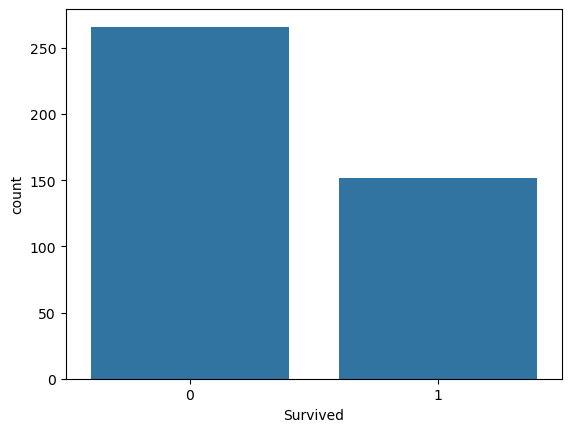

In [11]:
sns.countplot(x='Survived', data=df)
plt.show()
#0 for died 
# 1 for survive 

In [12]:
#Survival by Gender 
pd.crosstab(df['Sex'], df['Survived'])

Survived,0,1
Sex,,
female,0,152
male,266,0


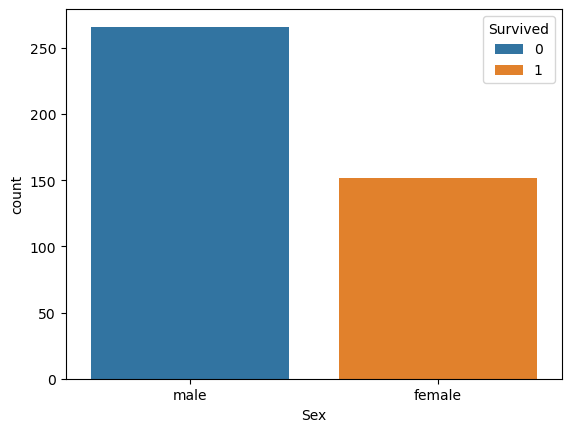

In [13]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.show()

In [14]:
#Survival rate by Gender 
survival_rate = pd.crosstab(
    df['Sex'],
    df['Survived'],
    normalize='index'
) * 100

print(survival_rate)

Survived      0      1
Sex                   
female      0.0  100.0
male      100.0    0.0


FEMALE HAVE A MUCH HIGHER SURVIVAL RATE THEN MALE

In [15]:
#Survival By Passenger Class 
pd.crosstab(df['Pclass'], df['Survived'])

Survived,0,1
Pclass,,
1,57,50
2,63,30
3,146,72


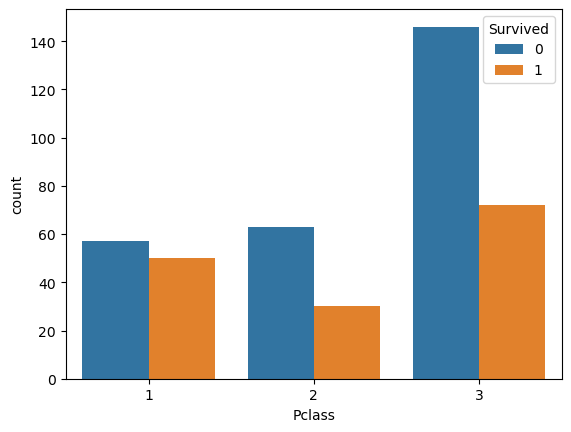

In [16]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.show()

In [17]:
#Survival Rate by Class
pd.crosstab(
    df['Pclass'],
    df['Survived'],
    normalize='index'
)*100

Survived,0,1
Pclass,,
1,53.271028,46.728972
2,67.741935,32.258065
3,66.972477,33.027523


1st Class passengers survived more frequently than 3rd Class passengers.

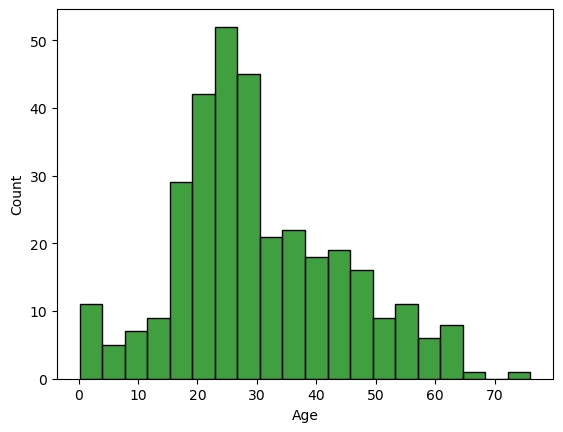

In [18]:
#AGE DISTRIBUTION 
sns.histplot(df['Age'], bins=20,color="green")
plt.show()

FIND THAT MOSTLY  PEOPLE ARE BETWEEN 20 TO 40 YEARS 

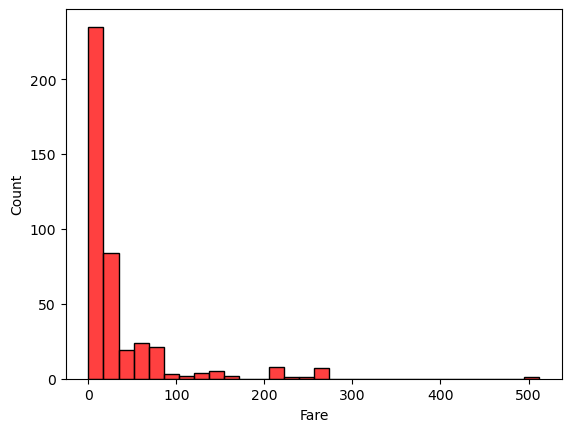

In [19]:
#FARE DISTRIBUTION
sns.histplot(df['Fare'], bins=30,color="red")
plt.show()

Distribution is highly right skewed.

Few passengers paid extremely high fares.

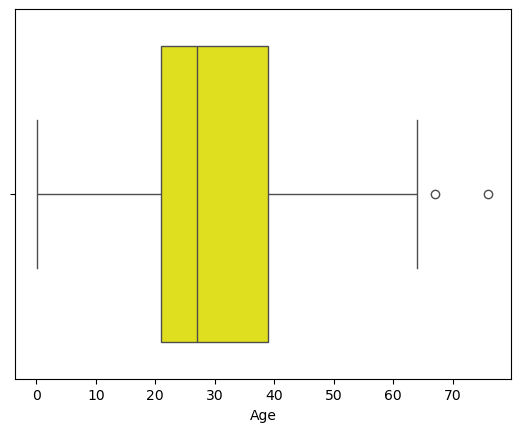

In [20]:
#DETECT ANOMOLIES 
sns.boxplot(x=df['Age'],color="yellow")
plt.show()

Babies (<1 year)
Elderly passengers (>70 years)

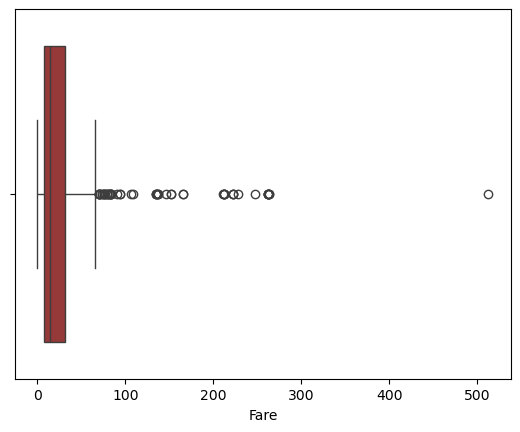

In [21]:
sns.boxplot(x=df['Fare'],color="brown")
plt.show()

In [22]:
#FARE OUTLIERS
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df['Fare'] < Q1 - 1.5*IQR) |
    (df['Fare'] > Q3 + 1.5*IQR)
]

print("Number of Fare Outliers:", len(outliers))

Number of Fare Outliers: 55


Some passengers paid fares above 500.

These are strong outliers.

QUESTION 4 

Test hypotheses and validate assumptions using statistics and visualization.

In [23]:
# DOES GENDER AFFECT SURVIVAL
# H0 GENDER HAS NO RELATION SHIP WITH SURVIVAL
# H1 GENDER AFFECT SURVIVAL 
# TO CHECK WE CAN USE USED CHI SQUARE TEST METHOD 
from scipy.stats import chi2_contingency
table = pd.crosstab(df['Sex'], df['Survived'])
chi2, p, dof, expected = chi2_contingency(table)
print("P-value:", p)

P-value: 5.767311139789629e-92


In [24]:
#DECISON FOR H0 OR H1 
if p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Reject H0


ITS MEANS GENDER AFFECT SURVIVAL RATE 

In [25]:
#Does Passenger Class Affect Survival?
# H0 PASSENGER CLASS  HAS NO RELATION SHIP WITH SURVIVAL
# H1 PASSENGER CLASS  AFFECT SURVIVAL 
# TO CHECK WE CAN USE USED CHI SQUARE TEST METHOD 
from scipy.stats import chi2_contingency
table = pd.crosstab(df['Pclass'], df['Survived'])
chi2, p, dof, expected = chi2_contingency(table)
print("P-Value",p)


P-Value 0.03519206276590605


In [26]:
if p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Reject H0


Passenger class significantly affects survival.

In [27]:
#Do Survivors Have Different Ages?
# H0 AGE HAS NO RELATION SHIP WITH SURVIVAL
# H1 AGE AFFECT SURVIVAL 
# TO CHECK WE CAN USE USED CHI SQUARE TEST METHOD 
from scipy.stats import ttest_ind
survived = df[df['Survived']==1]['Age'].dropna()
dead = df[df['Survived']==0]['Age'].dropna()
t_stat, p = ttest_ind(survived, dead)
print("P-Value",p)


P-Value 0.9998163174099579


In [28]:
if p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Fail to Reject H0


Age does not show a statistically significant effect on survival in this dataset (p > 0.05).

In [29]:
#CORRELATION ANALYSIS 
numeric = df.select_dtypes(include='number')
numeric.corr()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.023245,-0.026751,-0.034102,0.003818,0.043080,0.008211
Survived,-0.023245,1.000000,-0.108615,-0.000013,0.099943,0.159120,0.191514
Pclass,-0.026751,-0.108615,1.000000,-0.492143,0.001087,0.018721,-0.577147
Age,-0.034102,-0.000013,-0.492143,1.000000,-0.091587,-0.061249,0.337932
SibSp,0.003818,0.099943,0.001087,-0.091587,1.000000,0.306895,0.171539
Parch,0.043080,0.159120,0.018721,-0.061249,0.306895,1.000000,0.230046
Fare,0.008211,0.191514,-0.577147,0.337932,0.171539,0.230046,1.000000


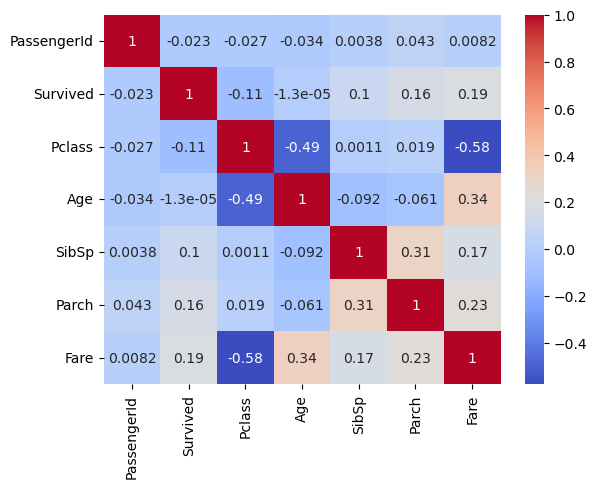

In [30]:
sns.heatmap(numeric.corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

QUESTION 5

Detect potential data issues or problems to address in further analysis

In [31]:
#MISSING VALUES 
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

In [32]:
#CHECK MISSING VALUES GONE OR NOT 
df[['Age', 'Fare']].isnull().sum()

Age     0
Fare    0
dtype: int64

In [33]:
#SKEWED DISTRIBUTION
#FARE IS HIGHLY SKEWED 
import numpy as np
df['Fare'] = np.log1p(df['Fare'])

In [34]:
#CATEGORICAL VALUE
df_encoded = pd.get_dummies(
    df,
    columns=['Sex','Embarked'],
    drop_first=True
)
df_encoded.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_male,Embarked_Q,Embarked_S
0,892,0,3,"Kelly, Mr. James",34.5,0,0,330911,2.178064,NaN,True,True,False
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",47.0,1,0,363272,2.079442,NaN,False,False,True
2,894,0,2,"Myles, Mr. Thomas Francis",62.0,0,0,240276,2.369075,NaN,True,True,False
3,895,0,3,"Wirz, Mr. Albert",27.0,0,0,315154,2.268252,NaN,True,False,True
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",22.0,1,1,3101298,2.586824,NaN,False,False,True


FINAL CONCULSION


Data Overview

The dataset contains 418 passenger records and 12 variables including demographic information, ticket details, and survival status.